Section 1 – Project Introduction (Markdown)

Create a Markdown cell.

# Brazilian E-Commerce (Olist) Dataset – Data Understanding

## Objective

The objective of this notebook is to understand the structure of the Brazilian E-Commerce (Olist) dataset before performing any preprocessing or analysis.

The notebook covers:

- Loading all dataset files
- Understanding each dataset
- Inspecting data types
- Checking missing values
- Generating descriptive statistics
- Understanding relationships between tables
- Identifying numerical, categorical, and datetime columns
- Preparing the datasets for data cleaning

Section 2 – Import Required Libraries

Create a Code cell.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot settings
plt.style.use("ggplot")

Section 3 – Load the Datasets

Since all CSV files are inside:

In [2]:
customers = pd.read_csv("../dataset/raw/olist_customers_dataset.csv")

orders = pd.read_csv("../dataset/raw/olist_orders_dataset.csv")

order_items = pd.read_csv("../dataset/raw/olist_order_items_dataset.csv")

payments = pd.read_csv("../dataset/raw/olist_order_payments_dataset.csv")

reviews = pd.read_csv("../dataset/raw/olist_order_reviews_dataset.csv")

products = pd.read_csv("../dataset/raw/olist_products_dataset.csv")

sellers = pd.read_csv("../dataset/raw/olist_sellers_dataset.csv")

geolocation = pd.read_csv("../dataset/raw/olist_geolocation_dataset.csv")

translation = pd.read_csv("../dataset/raw/product_category_name_translation.csv")

Section 4 – Store All DataFrames

Instead of writing repetitive code, create a dictionary:

In [ ]:
datasets = {
    "Customers": customers,
    "Orders": orders,
    "Order Items": order_items,
    "Payments": payments,
    "Reviews": reviews,
    "Products": products,
    "Sellers": sellers,
    "Geolocation": geolocation,
    "Translation": translation
}

Section 5 – Display Basic Information

In [4]:
for name, df in datasets.items():
    print("=" * 70)
    print(f"{name}")
    print("=" * 70)

    print(f"Rows    : {df.shape[0]}")
    print(f"Columns : {df.shape[1]}")

    display(df.head())

Customers
Rows    : 99441
Columns : 5


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


Orders
Rows    : 99441
Columns : 8


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


Order Items
Rows    : 112650
Columns : 7


...

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


Geolocation
Rows    : 1000163
Columns : 5


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


Translation
Rows    : 71
Columns : 2


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


Section 6 – Display Dataset Dimensions

In [5]:
dimension_summary = pd.DataFrame(
    {
        "Dataset": datasets.keys(),
        "Rows": [df.shape[0] for df in datasets.values()],
        "Columns": [df.shape[1] for df in datasets.values()],
    }
)

dimension_summary

,Dataset,Rows,Columns
0,Customers,99441,5
1,Orders,99441,8
2,Order Items,112650,7
3,Payments,103886,5
4,Reviews,99224,7
5,Products,32951,9
6,Sellers,3095,4
7,Geolocation,1000163,5
8,Translation,71,2


Section 7 – Visualize Table Sizes

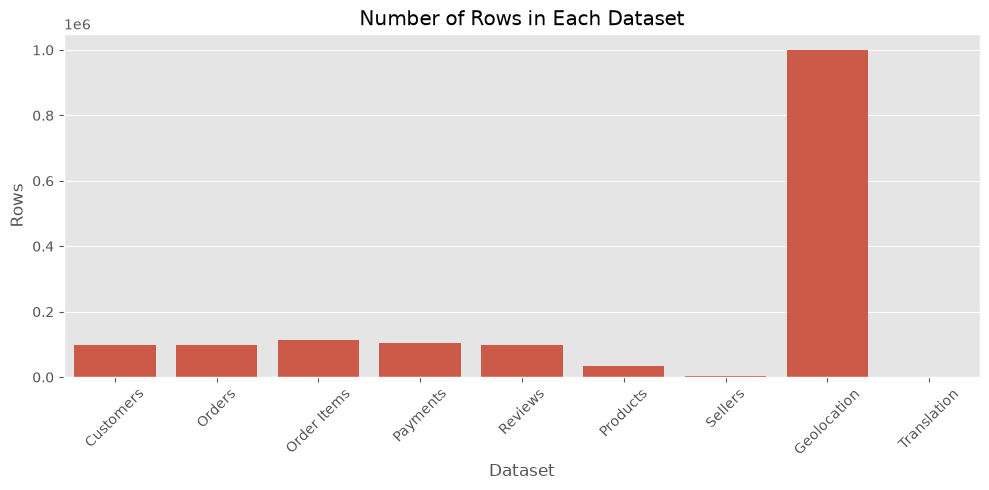

In [6]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=dimension_summary,
    x="Dataset",
    y="Rows"
)

plt.xticks(rotation=45)
plt.title("Number of Rows in Each Dataset")
plt.tight_layout()

plt.show()

Section 8 – Inspect Dataset Information
Objective

Understand the internal structure of every dataset by examining:

Number of rows and columns
Column names
Data types
Missing values
Memory usage

Instead of calling info() manually for every dataset, we'll loop through all of them.

In [7]:
for name, df in datasets.items():

    print("=" * 80)
    print(f"{name.upper()} DATASET")
    print("=" * 80)

    df.info()

    print("\n")

CUSTOMERS DATASET
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


ORDERS DATASET
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   o

Section 9 – Data Type Summary

Instead of reading every info() output manually, create a summary table.

In [8]:
datatype_summary = []

for name, df in datasets.items():

    for column in df.columns:

        datatype_summary.append({
            "Dataset": name,
            "Column": column,
            "Data Type": df[column].dtype
        })

datatype_summary = pd.DataFrame(datatype_summary)

datatype_summary.head(20)

,Dataset,Column,Data Type
0,Customers,customer_id,str
1,Customers,customer_unique_id,str
2,Customers,customer_zip_code_prefix,int64
3,Customers,customer_city,str
4,Customers,customer_state,str
5,Orders,order_id,str
6,Orders,customer_id,str
7,Orders,order_status,str
8,Orders,order_purchase_timestamp,str
9,Orders,order_approved_at,str


Section 10 – Visualize Data Types

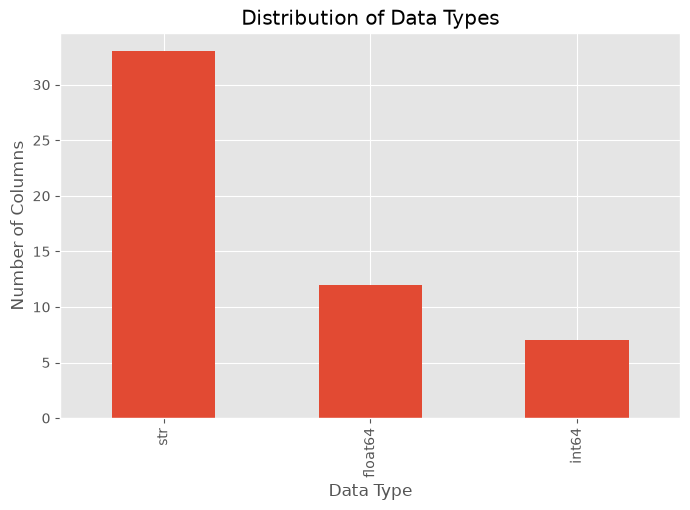

In [9]:
plt.figure(figsize=(8,5))

datatype_summary["Data Type"].value_counts().plot(
    kind="bar"
)

plt.title("Distribution of Data Types")
plt.xlabel("Data Type")
plt.ylabel("Number of Columns")

plt.show()

Section 11 – Dataset Statistics

Now generate descriptive statistics for every dataset.

In [10]:
for name, df in datasets.items():

    print("=" * 80)
    print(name.upper())
    print("=" * 80)

    display(df.describe(include="all"))

CUSTOMERS


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,06b8999e2fba1a1fbc88172c00ba8bc7,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


ORDERS


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-03-31 15:08:21,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


ORDER ITEMS


...

,seller_id,seller_zip_code_prefix,seller_city,seller_state
count,3095,3095.000000,3095,3095
unique,3095,NaN,611,23
top,3442f8959a84dea7ee197c632cb2df15,NaN,sao paulo,SP
freq,1,NaN,694,1849
mean,NaN,32291.059451,NaN,NaN
std,NaN,32713.453830,NaN,NaN
min,NaN,1001.000000,NaN,NaN
25%,NaN,7093.500000,NaN,NaN
50%,NaN,14940.000000,NaN,NaN
75%,NaN,64552.500000,NaN,NaN


GEOLOCATION


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
count,1.000163e+06,1.000163e+06,1.000163e+06,1000163,1000163
unique,NaN,NaN,NaN,8011,27
top,NaN,NaN,NaN,sao paulo,SP
freq,NaN,NaN,NaN,135800,404268
mean,3.657417e+04,-2.117615e+01,-4.639054e+01,NaN,NaN
std,3.054934e+04,5.715866e+00,4.269748e+00,NaN,NaN
min,1.001000e+03,-3.660537e+01,-1.014668e+02,NaN,NaN
25%,1.107500e+04,-2.360355e+01,-4.857317e+01,NaN,NaN
50%,2.653000e+04,-2.291938e+01,-4.663788e+01,NaN,NaN
75%,6.350400e+04,-1.997962e+01,-4.376771e+01,NaN,NaN


TRANSLATION


,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


Section 12 – Numerical vs Categorical Columns

Let's identify column types for each dataset.

In [11]:
for name, df in datasets.items():

    numerical = df.select_dtypes(include=["number"]).columns.tolist()

    categorical = df.select_dtypes(include=["object"]).columns.tolist()

    datetime = df.select_dtypes(include=["datetime"]).columns.tolist()

    print("=" * 70)
    print(name)
    print("=" * 70)

    print(f"Numerical Columns ({len(numerical)})")
    print(numerical)

    print()

    print(f"Categorical Columns ({len(categorical)})")
    print(categorical)

    print()

    print(f"Datetime Columns ({len(datetime)})")
    print(datetime)

    print("\n")

Customers
Numerical Columns (1)
['customer_zip_code_prefix']

Categorical Columns (4)
['customer_id', 'customer_unique_id', 'customer_city', 'customer_state']

Datetime Columns (0)
[]


Orders
Numerical Columns (0)
[]

Categorical Columns (8)
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Datetime Columns (0)
[]


Order Items
Numerical Columns (3)
['order_item_id', 'price', 'freight_value']

Categorical Columns (4)
['order_id', 'product_id', 'seller_id', 'shipping_limit_date']

Datetime Columns (0)
[]


Payments
Numerical Columns (3)
['payment_sequential', 'payment_installments', 'payment_value']

Categorical Columns (2)
['order_id', 'payment_type']

Datetime Columns (0)
[]


Reviews
Numerical Columns (1)
['review_score']

Categorical Columns (6)
['review_id', 'order_id', 'review_comment_title', 'review_comment_message', 'review_creation_date'

/tmp/ipykernel_347600/3042709797.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = df.select_dtypes(include=["object"]).columns.tolist()
/tmp/ipykernel_347600/3042709797.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-s

Missing Value Analysis

Step 1 – Missing Values for Every Dataset

In [12]:
for name, df in datasets.items():

    print("=" * 80)
    print(f"{name.upper()} DATASET")
    print("=" * 80)

    missing = df.isnull().sum()

    missing = missing[missing > 0]

    if len(missing) == 0:
        print("No missing values.\n")

    else:
        print(missing)

    print()

CUSTOMERS DATASET
No missing values.


ORDERS DATASET
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

ORDER ITEMS DATASET
No missing values.


PAYMENTS DATASET
No missing values.


REVIEWS DATASET
review_comment_title      87656
review_comment_message    58247
dtype: int64

PRODUCTS DATASET
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

SELLERS DATASET
No missing values.


GEOLOCATION DATASET
No missing values.


TRANSLATION DATASET
No missing values.




Step 2 – Create a Missing Value Summary Table

Instead of printing dataset by dataset, let's build one combined table.

In [13]:
missing_summary = []

for dataset_name, df in datasets.items():

    total_rows = len(df)

    missing_counts = df.isnull().sum()

    missing_percentages = (
        missing_counts / total_rows
    ) * 100

    for column in df.columns:

        if missing_counts[column] > 0:

            missing_summary.append({
                "Dataset": dataset_name,
                "Column": column,
                "Missing Count": missing_counts[column],
                "Missing Percentage": round(
                    missing_percentages[column], 2
                )
            })

missing_summary = pd.DataFrame(missing_summary)

missing_summary

,Dataset,Column,Missing Count,Missing Percentage
0,Orders,order_approved_at,160,0.16
1,Orders,order_delivered_carrier_date,1783,1.79
2,Orders,order_delivered_customer_date,2965,2.98
3,Reviews,review_comment_title,87656,88.34
4,Reviews,review_comment_message,58247,58.70
5,Products,product_category_name,610,1.85
6,Products,product_name_lenght,610,1.85
7,Products,product_description_lenght,610,1.85
8,Products,product_photos_qty,610,1.85
9,Products,product_weight_g,2,0.01


Step 3 – Sort the Summary

In [14]:
missing_summary.sort_values(
    by="Missing Percentage",
    ascending=False,
    inplace=True
)

missing_summary

,Dataset,Column,Missing Count,Missing Percentage
3,Reviews,review_comment_title,87656,88.34
4,Reviews,review_comment_message,58247,58.70
2,Orders,order_delivered_customer_date,2965,2.98
6,Products,product_name_lenght,610,1.85
5,Products,product_category_name,610,1.85
7,Products,product_description_lenght,610,1.85
8,Products,product_photos_qty,610,1.85
1,Orders,order_delivered_carrier_date,1783,1.79
0,Orders,order_approved_at,160,0.16
9,Products,product_weight_g,2,0.01


Step 4 – Missing Value Bar Chart

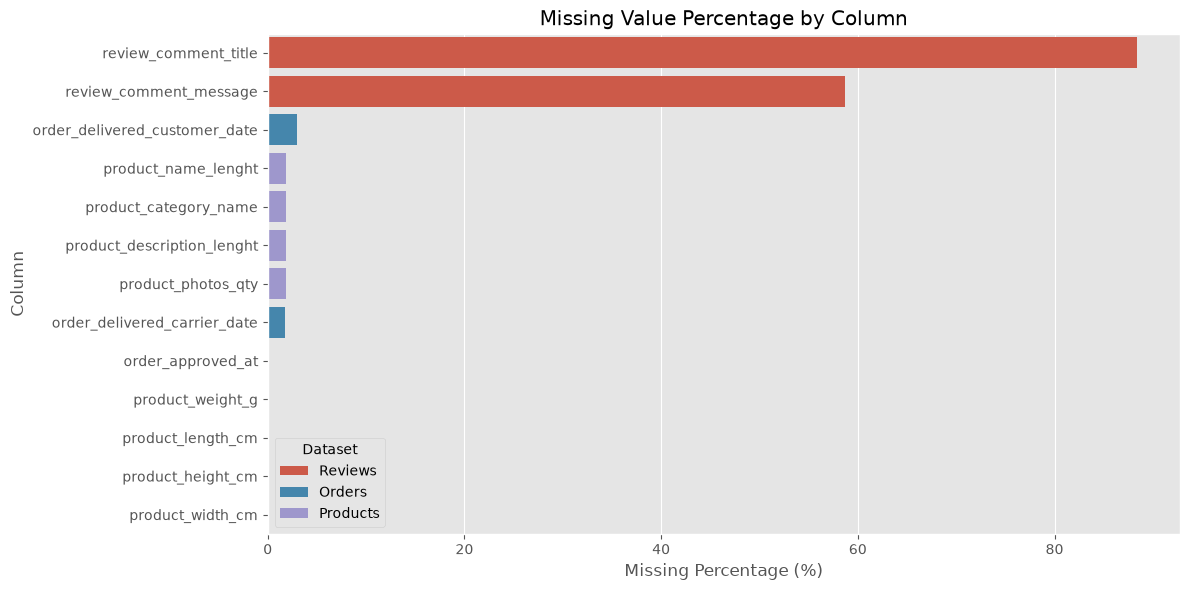

In [15]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=missing_summary,
    x="Missing Percentage",
    y="Column",
    hue="Dataset"
)

plt.title("Missing Value Percentage by Column")
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Column")

plt.tight_layout()

plt.show()

Step 5 – Missing Value Matrix

Now visualize missing values using the missingno library.

Customers


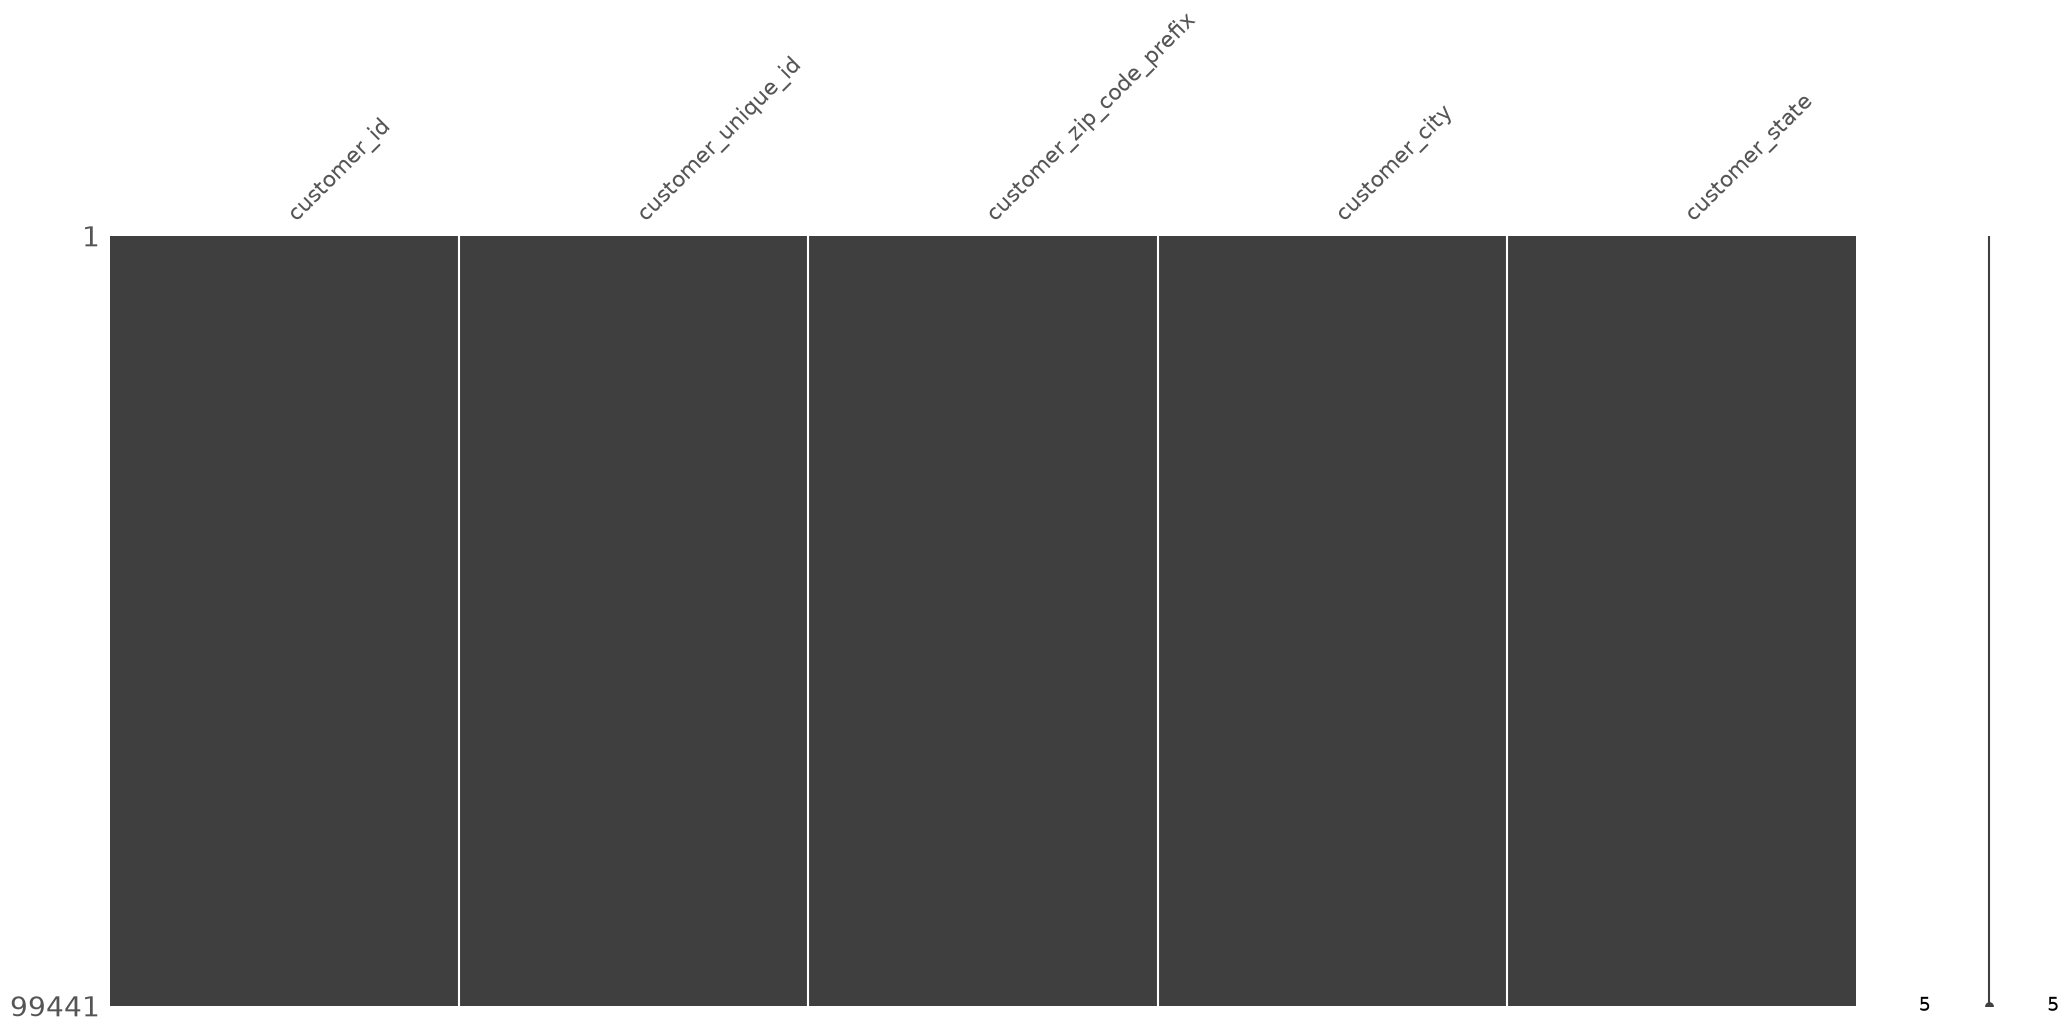

Orders


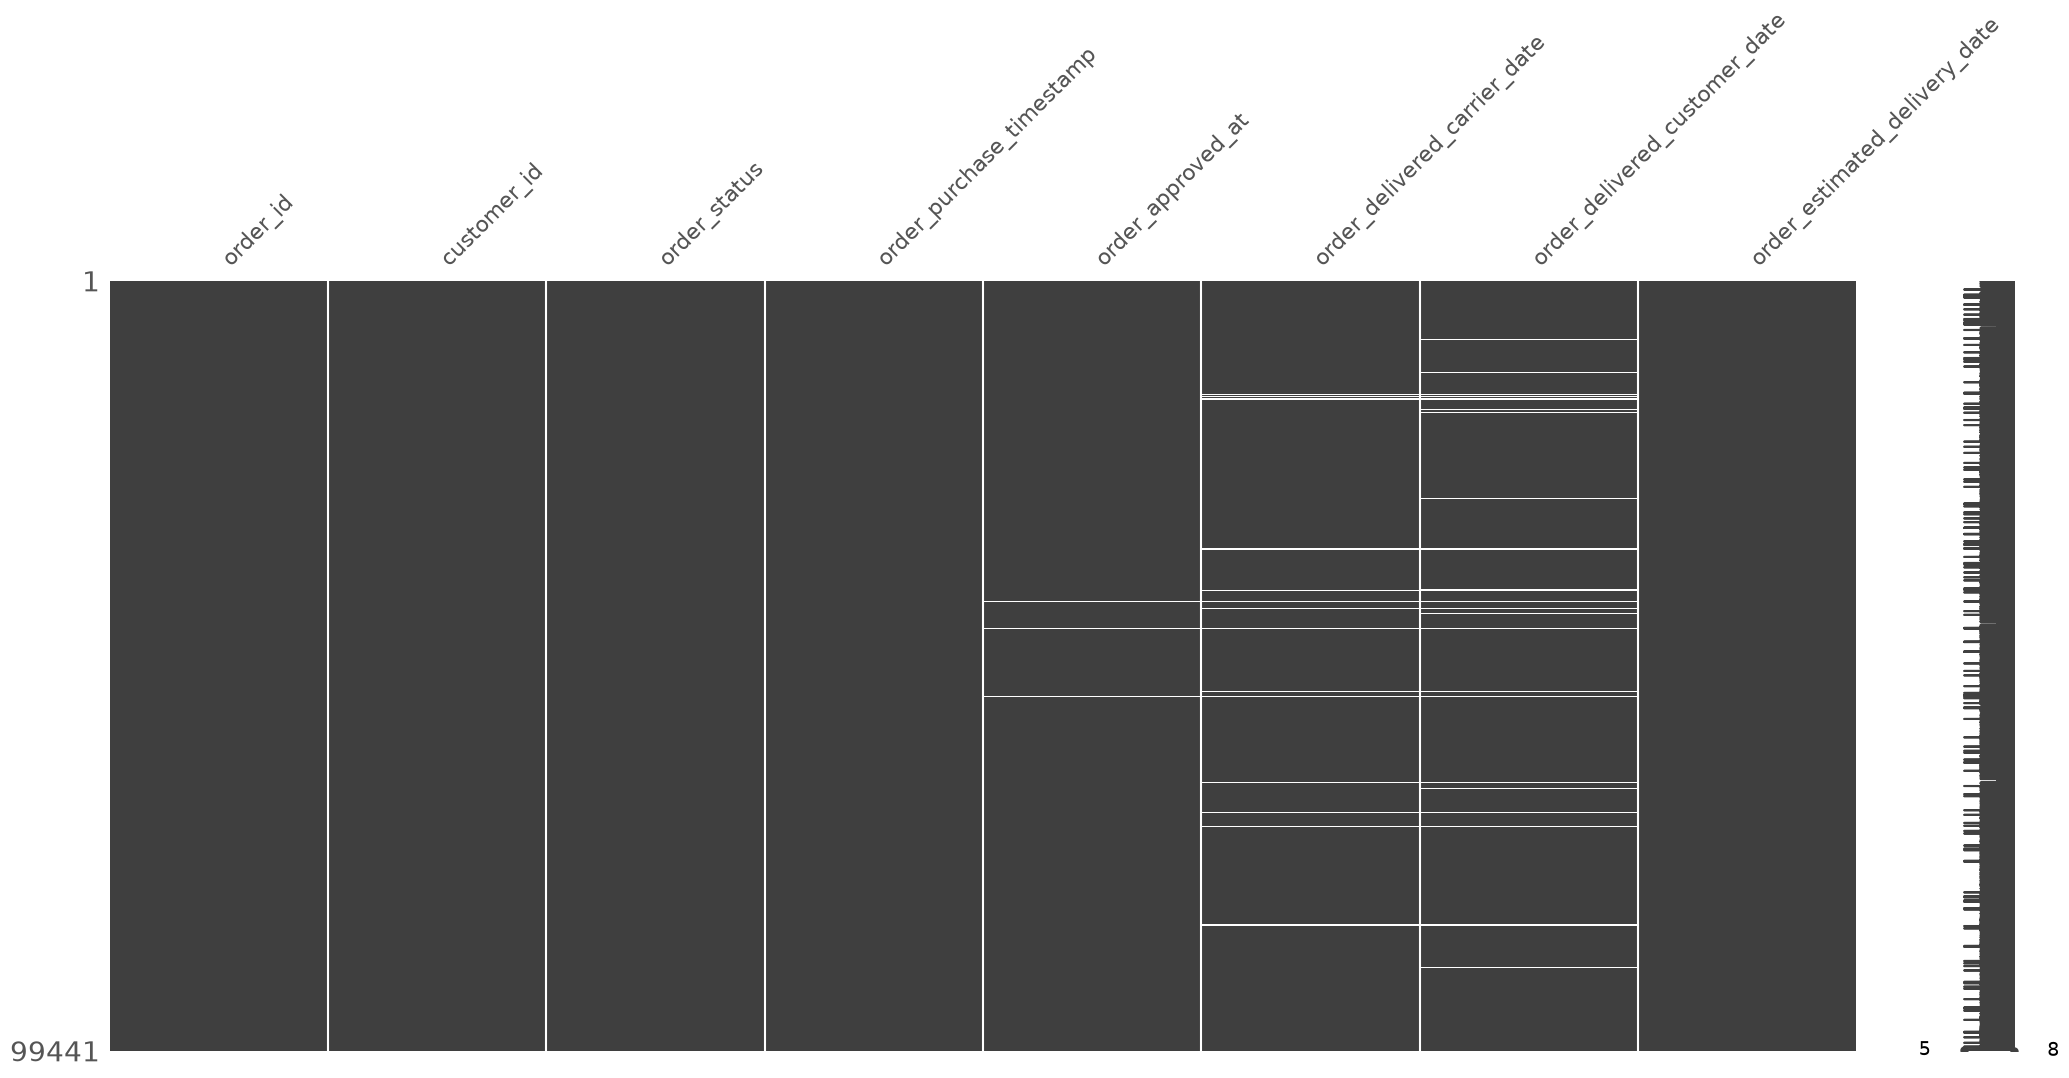

Order Items


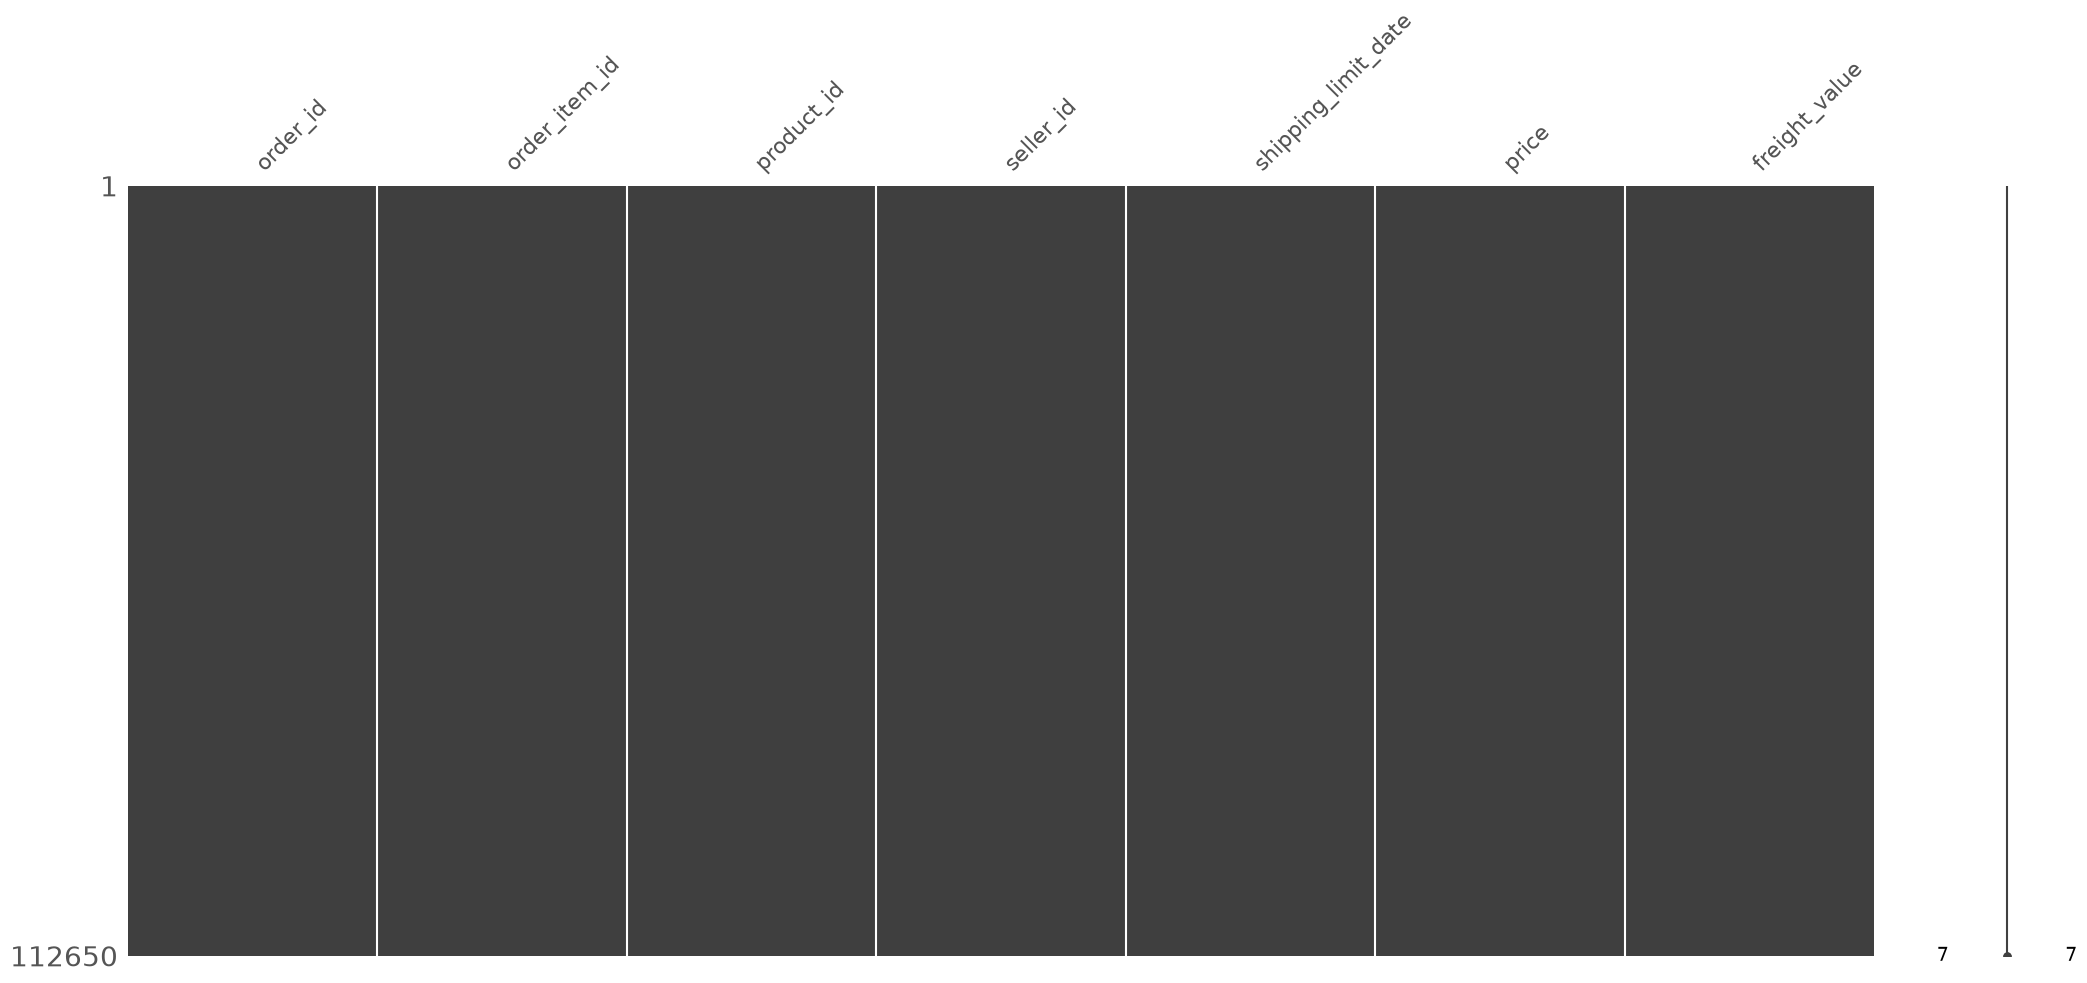

Payments


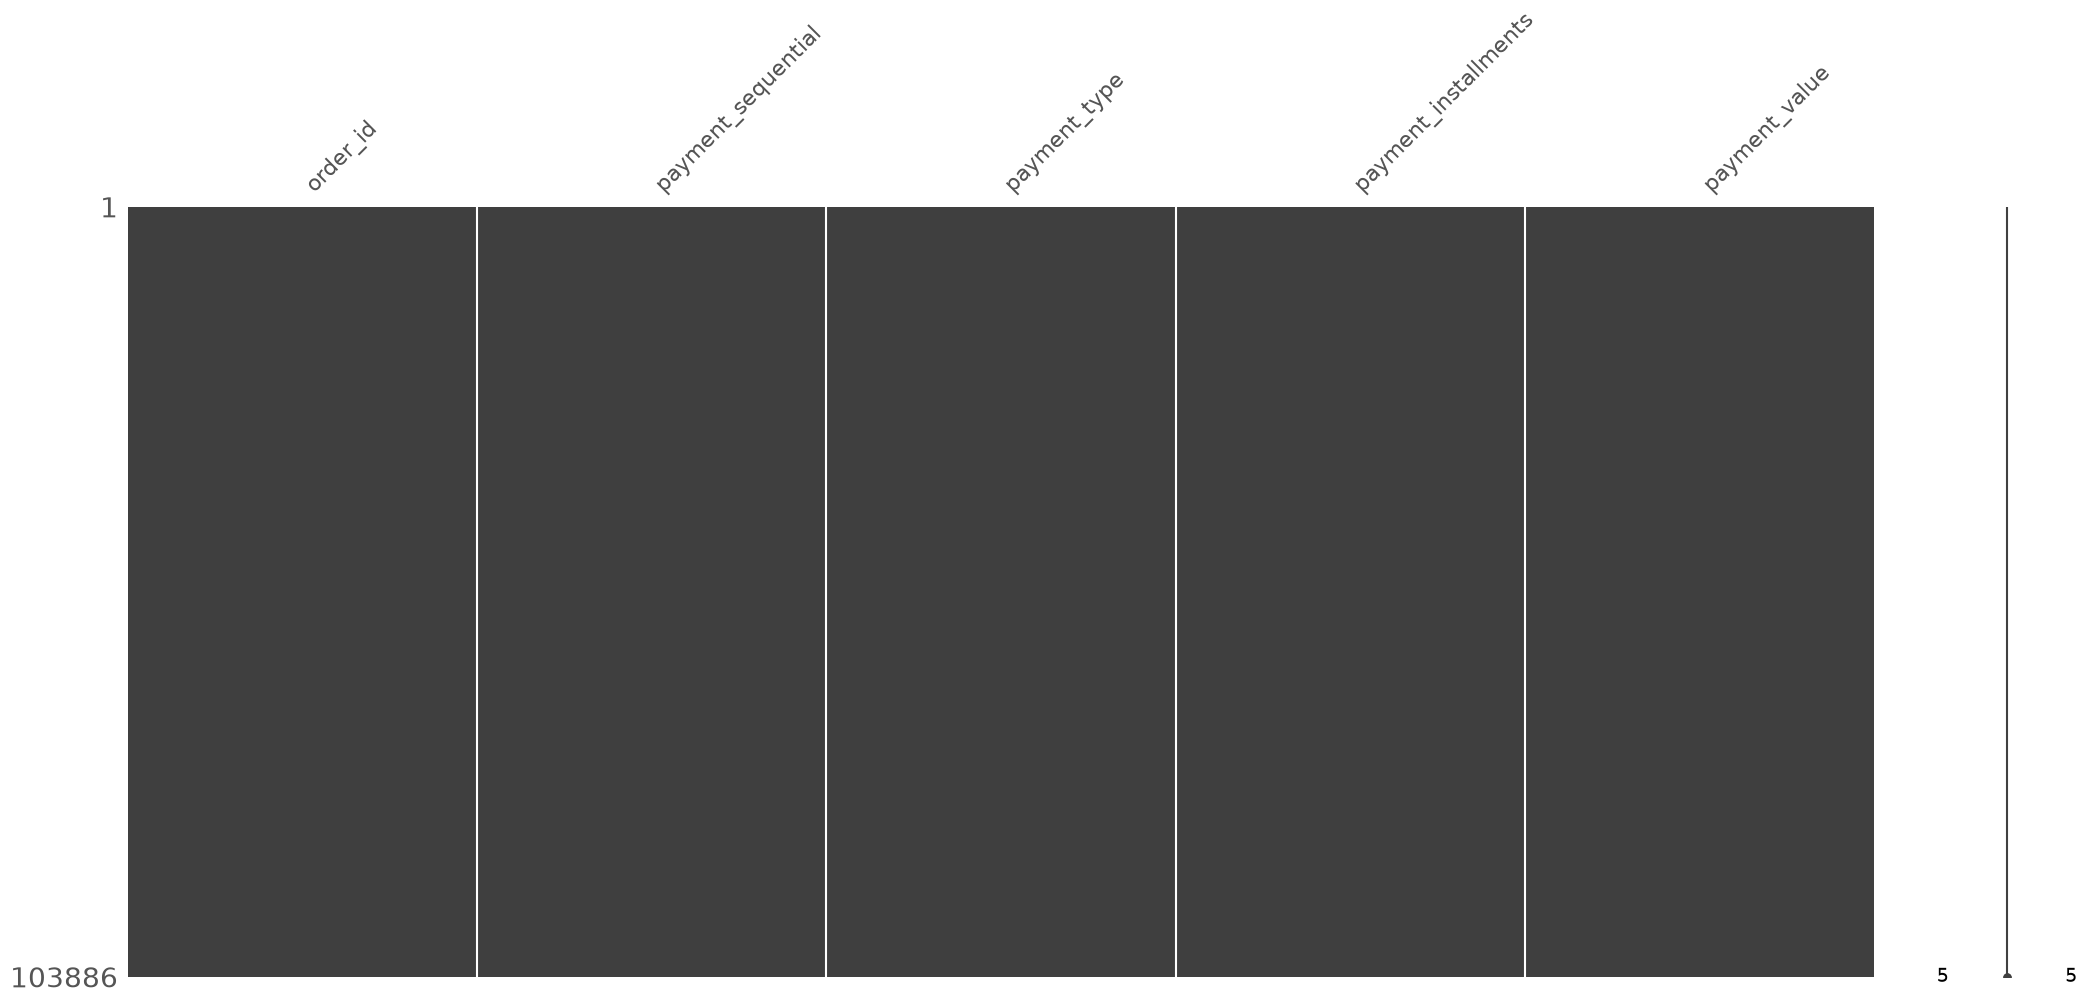

Reviews


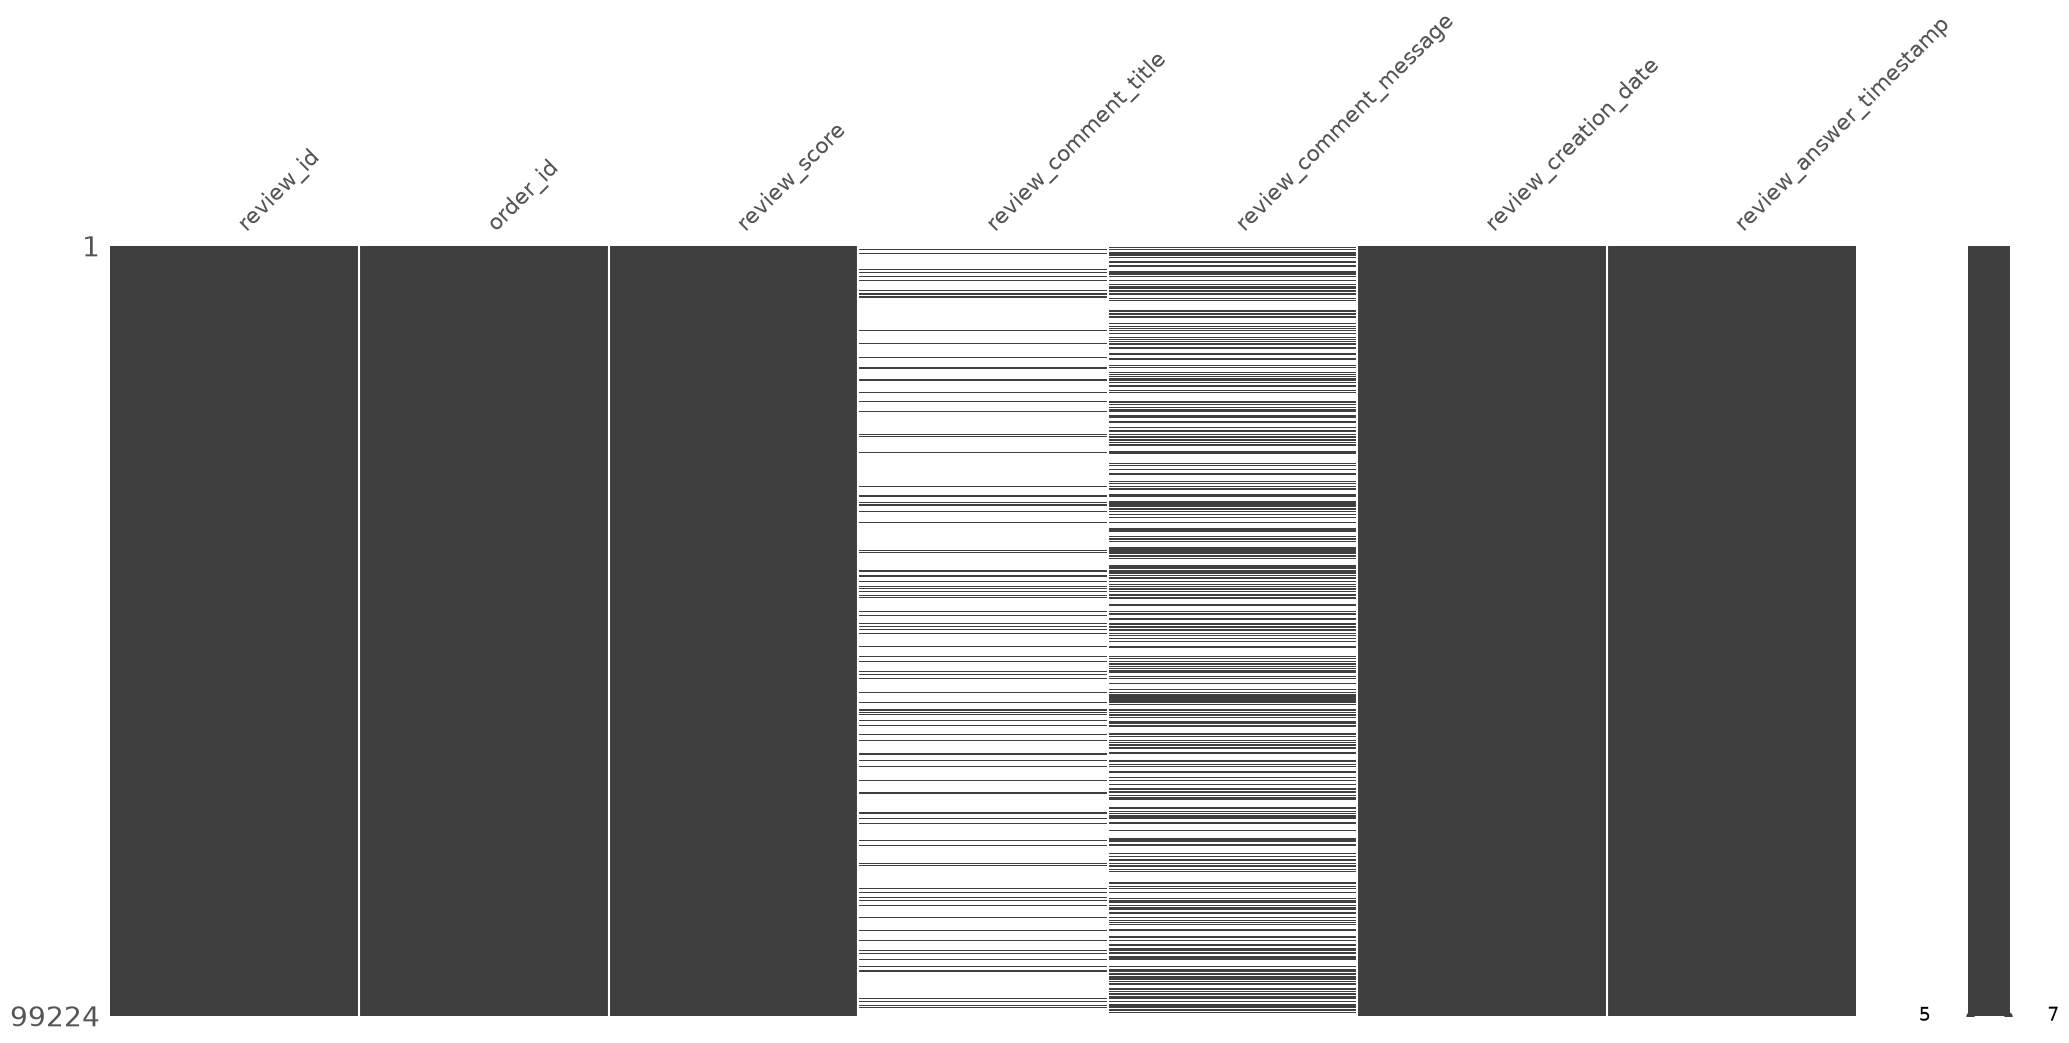

Products


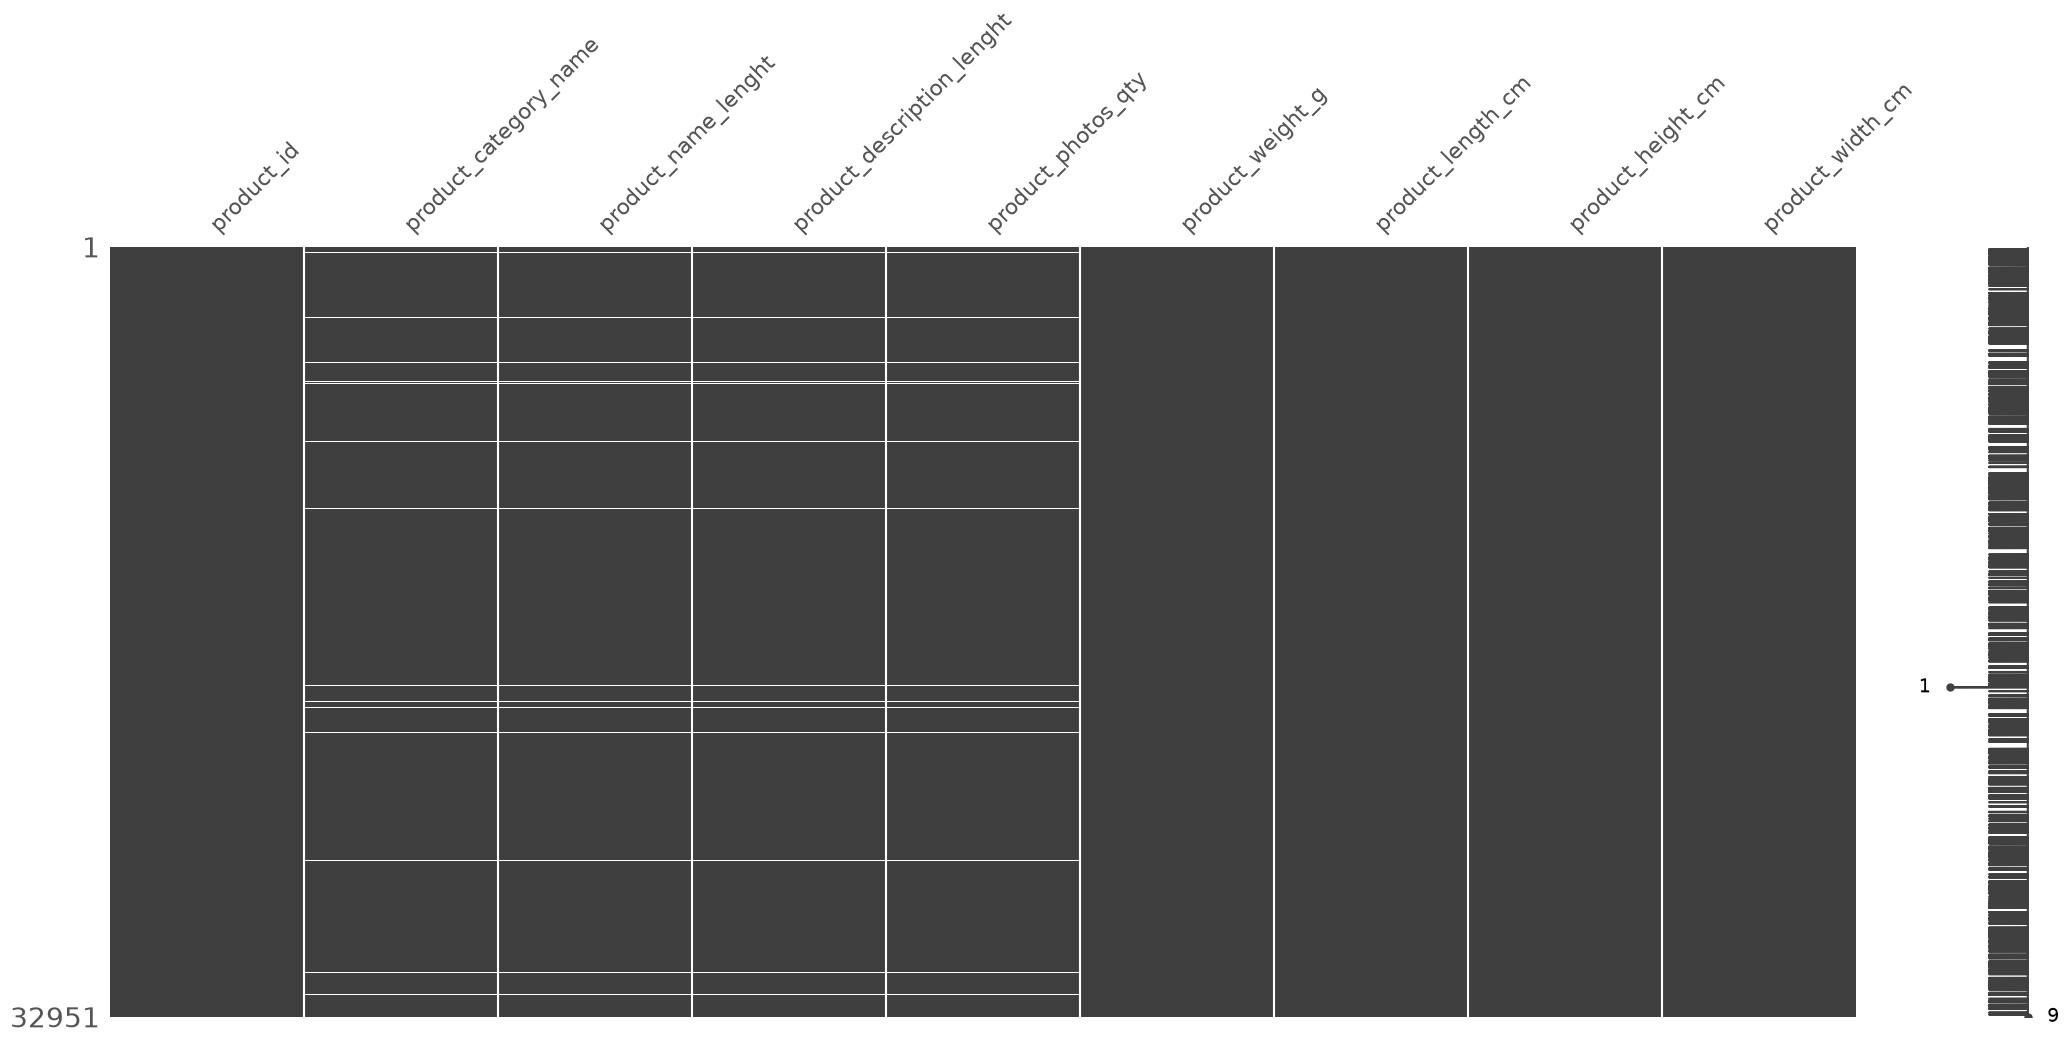

Sellers


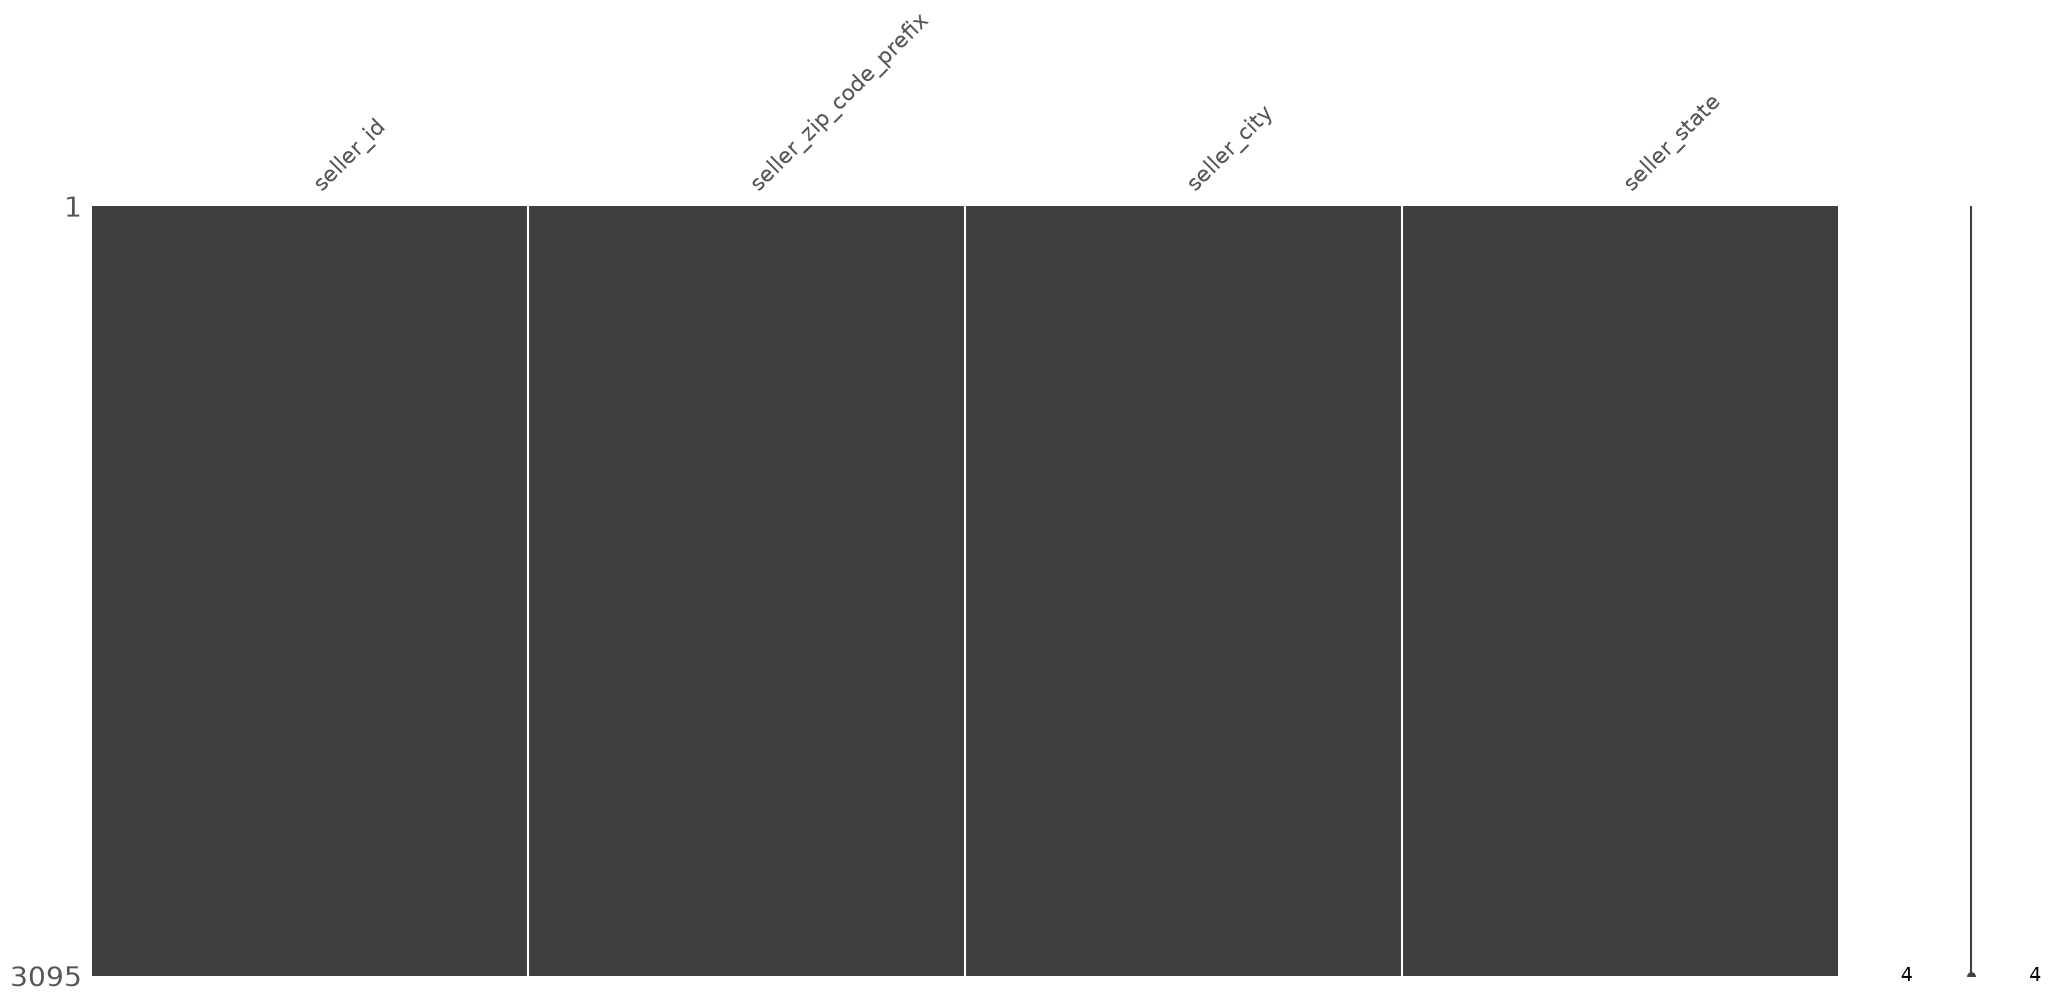

Geolocation


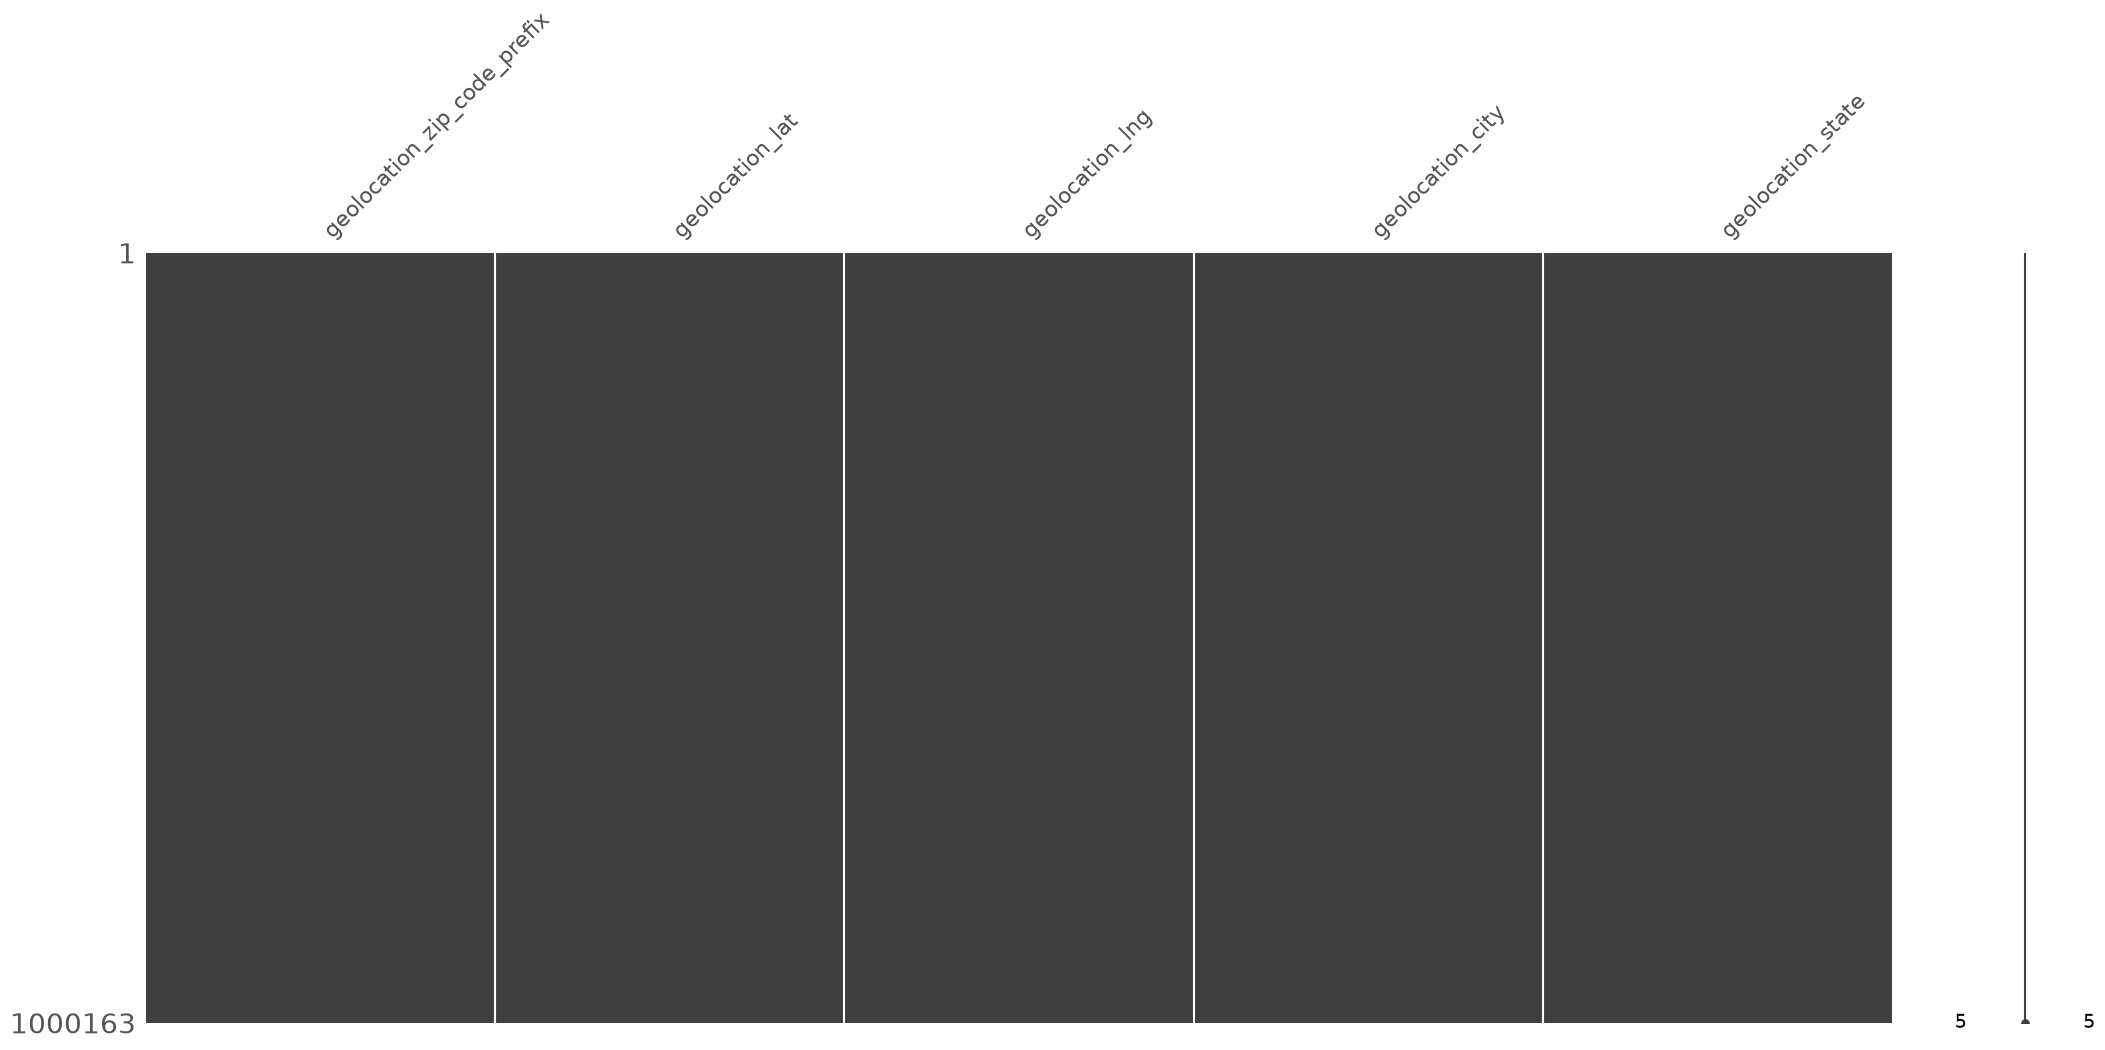

Translation


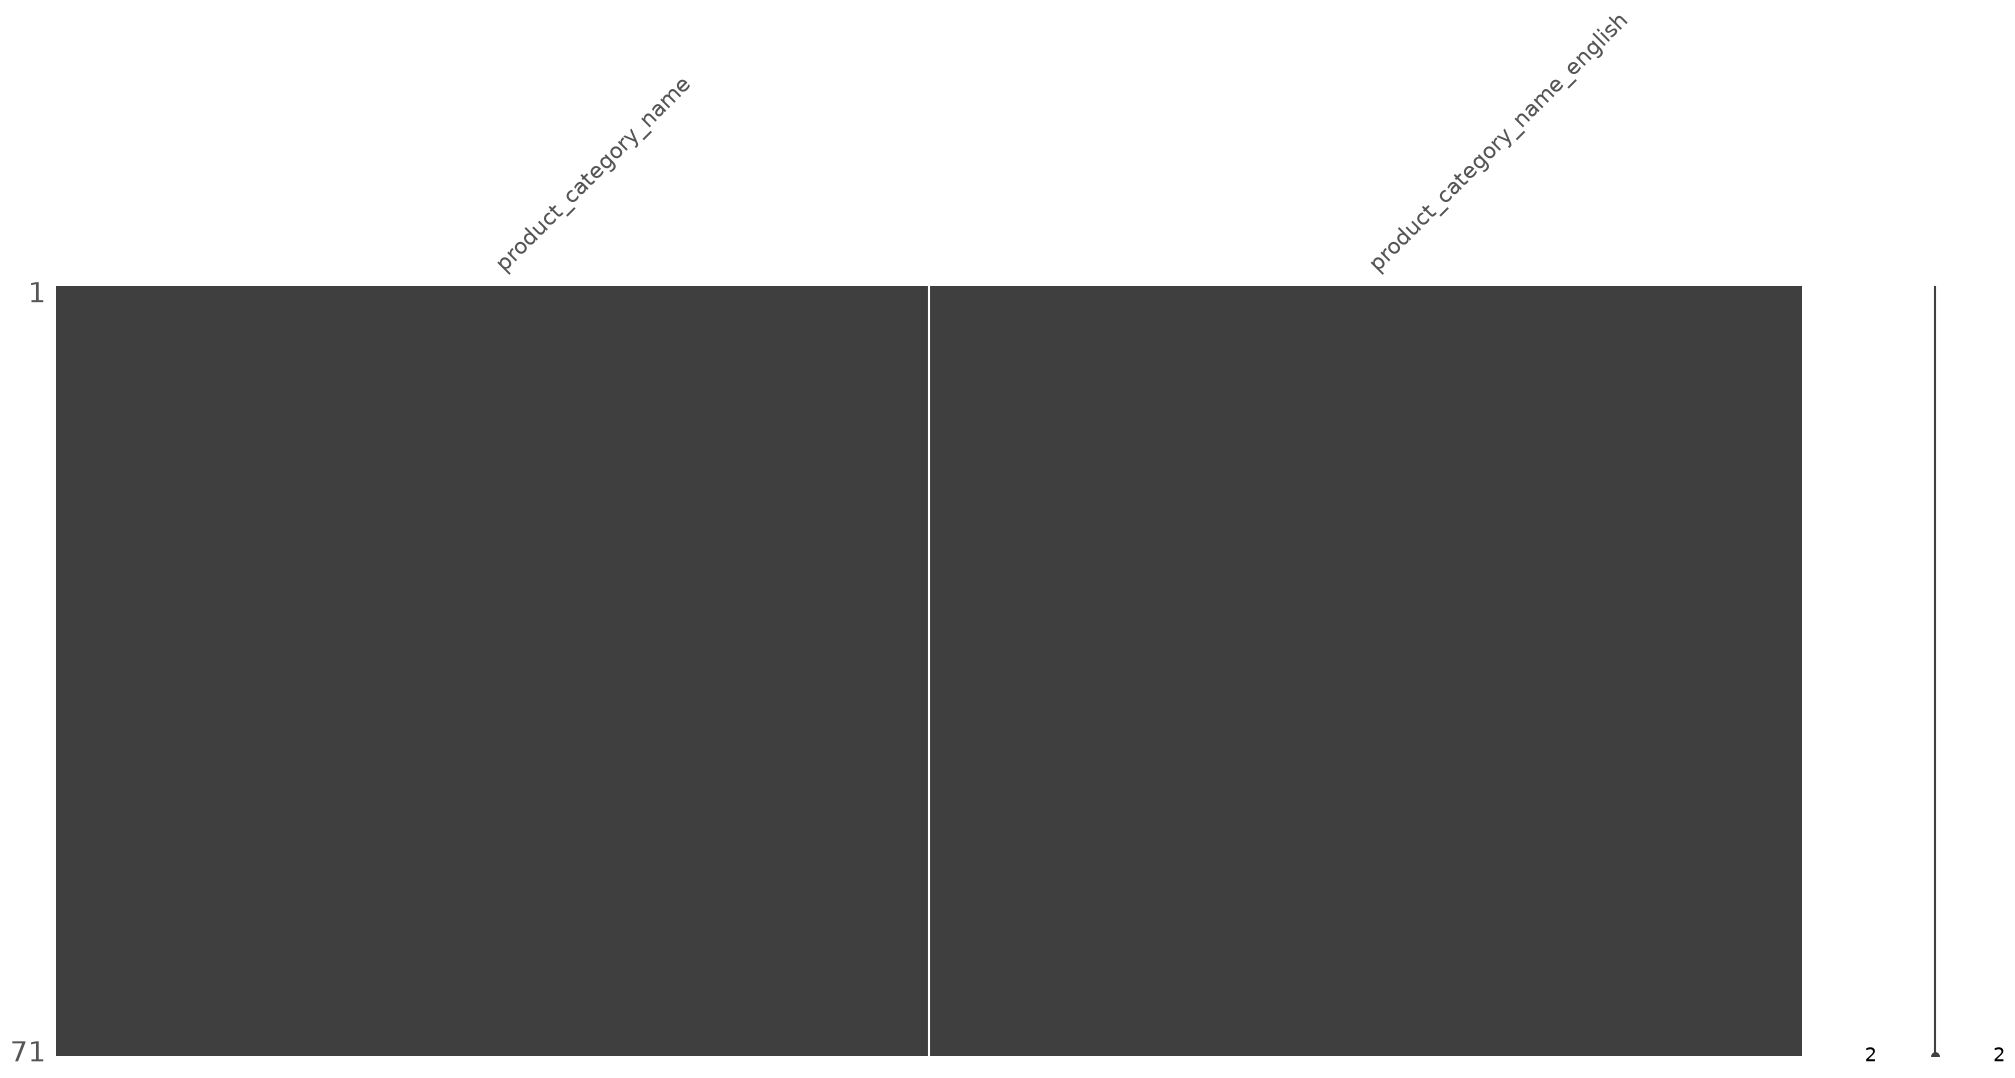

In [16]:
for name, df in datasets.items():

    print("=" * 70)
    print(name)
    print("=" * 70)

    msno.matrix(df)

    plt.show()

Step 6 – Missing Value Heatmap

Generate a heatmap only for datasets that contain missing values.

Orders


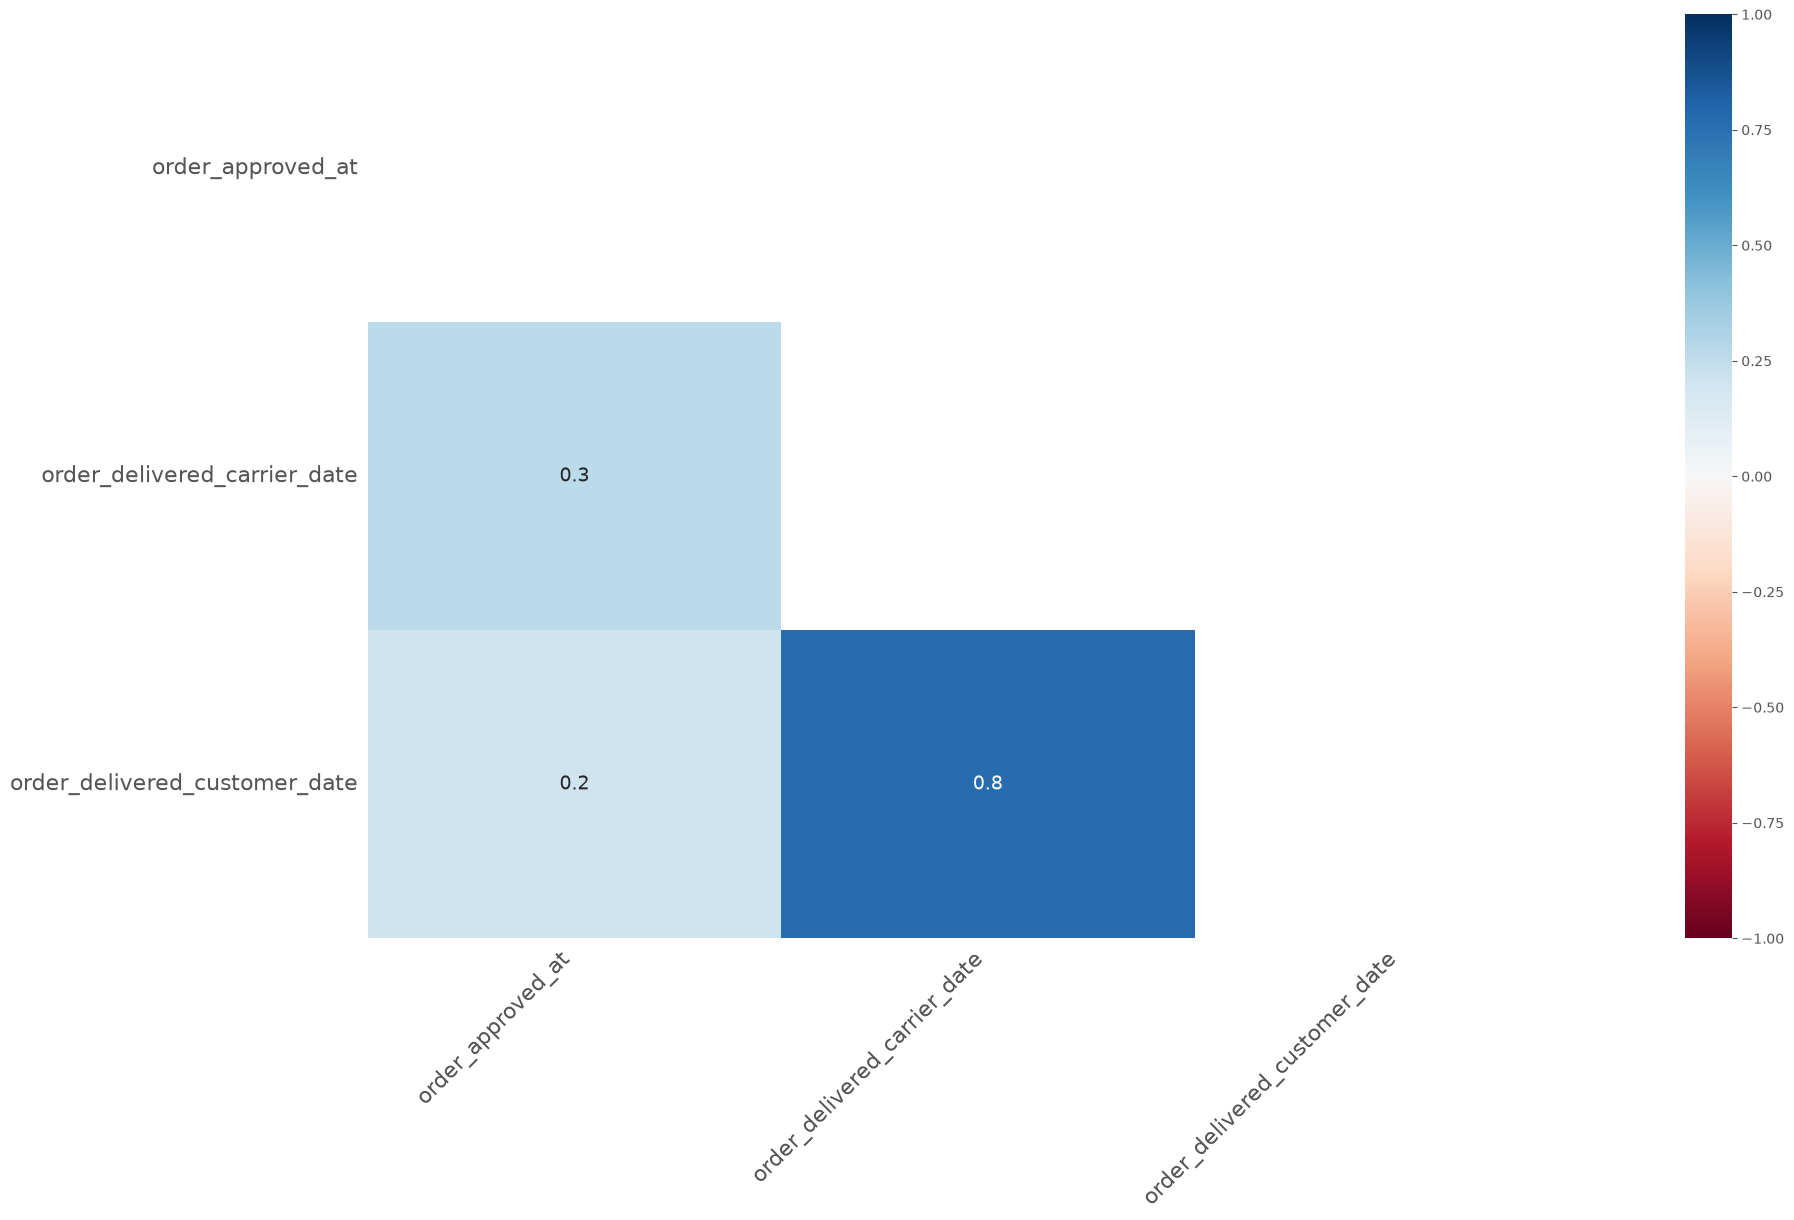

Reviews


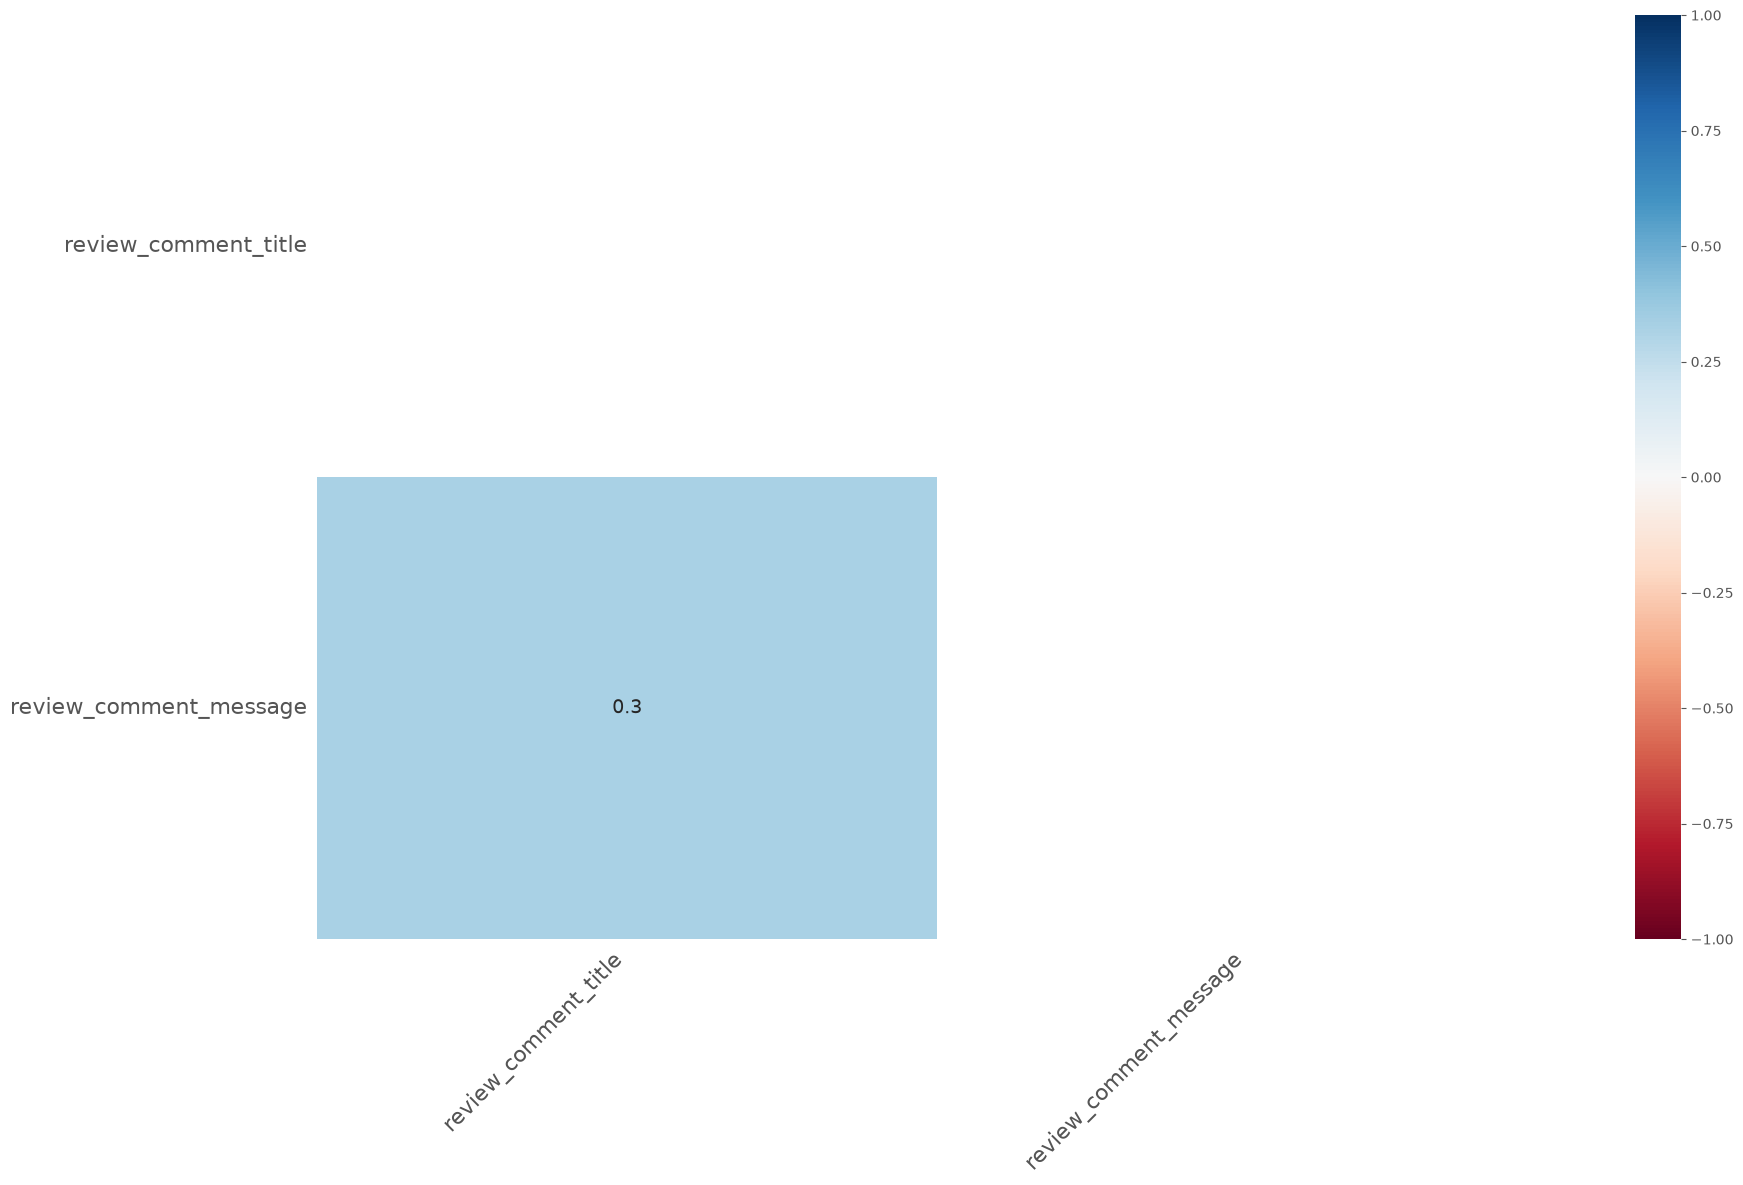

Products


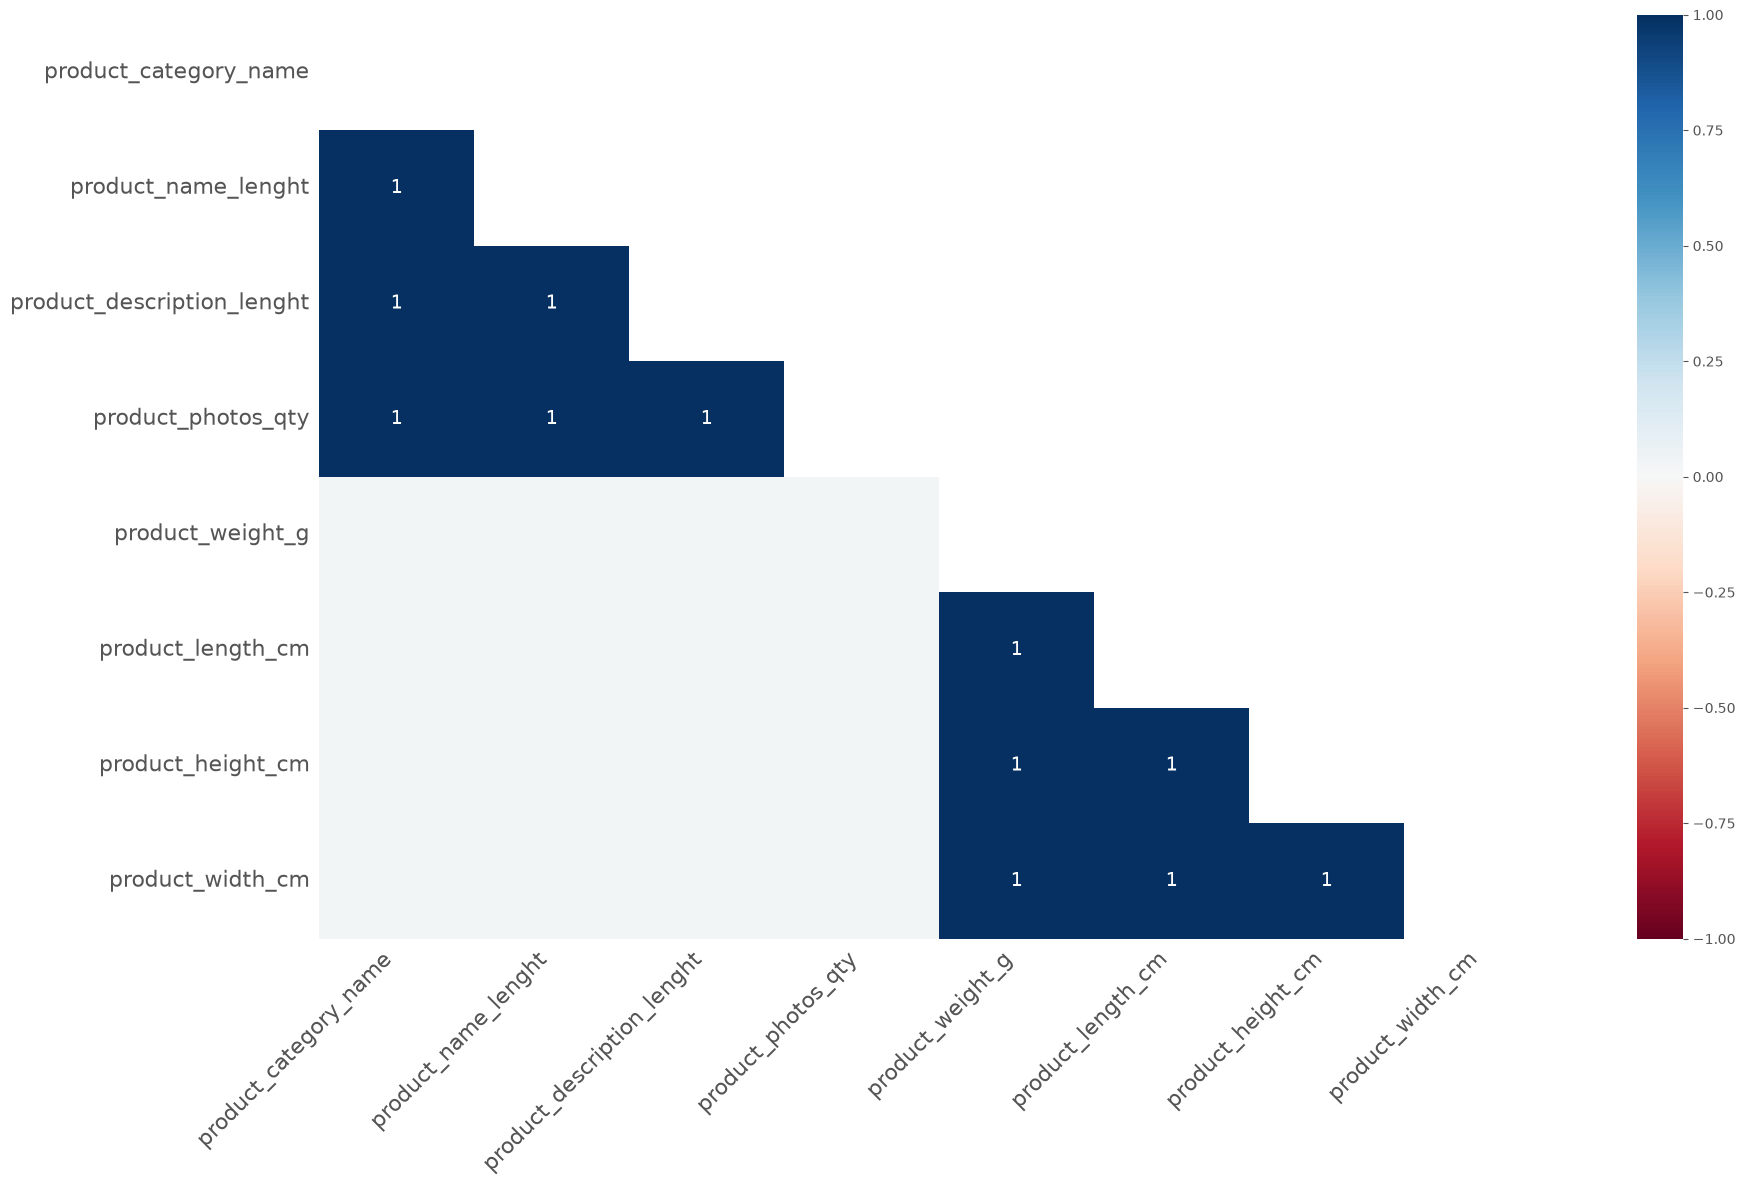

In [17]:
for name, df in datasets.items():

    if df.isnull().sum().sum() > 0:

        print("=" * 70)
        print(name)
        print("=" * 70)

        msno.heatmap(df)

        plt.show()

Step 7 – Missing Value Summary

You can also add a quick overview of missing values across datasets.

In [18]:
dataset_missing = pd.DataFrame(
    {
        "Dataset": datasets.keys(),
        "Total Missing Values": [
            df.isnull().sum().sum()
            for df in datasets.values()
        ]
    }
)

dataset_missing

,Dataset,Total Missing Values
0,Customers,0
1,Orders,4908
2,Order Items,0
3,Payments,0
4,Reviews,145903
5,Products,2448
6,Sellers,0
7,Geolocation,0
8,Translation,0
